In [1]:
# Импорт библиотек
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import display, clear_output

print("Все библиотеки загружены!")

Все библиотеки загружены!


Детектор Харриса — это классический алгоритм компьютерного зрения, разработанный Крисом Харрисом и Майком Стивенсом в 1988 году. Он используется для обнаружения углов на изображении.

В презе Беляева есть. ТОлько там формуда R другая

Первые моменты описывают положение центра масс объекта. В детекторе Харриса они не используются, но в компьютерном зрении они очень важны для других задач.

Вторые моменты (матрица M) описывают, как меняется яркость вокруг точки во всех направлениях. Это позволяет отличить угол от границы или плоской области.

1. Вычислить градиент изображения в каждом пикселе
• С использованием гауссова сглаживания
2. Вычислить матрицу вторых моментов М по окну вокруг каждого пикселя
3. Вычислить отклик угла R
4. Отрезать по порогу R
5. Найти локальные максимумы функции отклика (nonmaximum suppression) по окрестности заданного радиуса
6. Выбор N самых сильных локальных максимумов

In [2]:
def detect_keypoints_manual(image, max_points=500):

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    gray = np.float32(gray) # Преобразуем в другой формат (дальше операции с градиентами)

    block_size = 2 # Радиус окна свёртки вычисления моментов
    ksize = 3 # Размер ядра свертки для поиска градиентов
    k = 0.04  # Константа в формуле Харриса

    height, width = gray.shape
    harris_response = np.zeros((height, width))
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]) # Записываем ядра свёртки

    I_x = cv2.filter2D(gray, -1, sobel_x)
    I_y = cv2.filter2D(gray, -1, sobel_y) # проходим ядром по изображению (первые моменты)

    I_x2 = I_x * I_x
    I_y2 = I_y * I_y # Квадраты градиентов
    I_xy = I_x * I_y # Произведение градиентов (корреляция)

    for i in range(block_size, height - block_size): # Вычисляем отклик харриса
        for j in range(block_size, width - block_size):

            window_x2 = I_x2[i-block_size:i+block_size+1, j-block_size:j+block_size+1]
            window_y2 = I_y2[i-block_size:i+block_size+1, j-block_size:j+block_size+1]
            window_xy = I_xy[i-block_size:i+block_size+1, j-block_size:j+block_size+1] # Окна градиентов (вторых моментов)
            S_x2 = np.sum(window_x2)
            S_y2 = np.sum(window_y2)
            S_xy = np.sum(window_xy) # Сумма произведений градиентов

            M = np.array([[S_x2, S_xy], [S_xy, S_y2]]) # Матрица вторых моментов

            det = S_x2 * S_y2 - S_xy**2 # Определитель
            trace = S_x2 + S_y2 # След
            R = det - k * trace**2 # Мера угловатости

            harris_response[i, j] = R # Сохраняем значение отклика пикселя

    harris_response = cv2.normalize(harris_response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) # Нормализуем значение

    keypoints = [] # Создаем список для хранения точек
    adaptive_radius = max(5, min(width, height) // 100) # Радиус немаксимального подавления

    threshold = 50 # Порог отклика

    for i in range(adaptive_radius, height - adaptive_radius): # Перебор всех пикселей
        for j in range(adaptive_radius, width - adaptive_radius):
            
            if harris_response[i, j] < threshold: # Фильтр по порогу
                continue

            local_max = True
            for di in range(-adaptive_radius, adaptive_radius + 1): # Проверяем на наличие соседней точки с большим значением 
                for dj in range(-adaptive_radius, adaptive_radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    if i+di < 0 or i+di >= height or j+dj < 0 or j+dj >= width:
                        continue
                    if harris_response[i+di, j+dj] > harris_response[i, j]:
                        local_max = False
                        break
                        if not local_max:
                          break

            if local_max: # Создание ключевой точки
                kp = cv2.KeyPoint()
                kp.pt = (float(j), float(i))
                kp.size = adaptive_radius * 2
                kp.response = float(harris_response[i, j])
                keypoints.append(kp)

    keypoints = sorted(keypoints, key=lambda x: x.response, reverse=True) # Сортируем и возвращаем точки
    keypoints = keypoints[:max_points]

    return keypoints, gray

In [3]:
def compute_histogram(image):
    histogram = np.zeros(256, dtype=np.int32)
    height, width = image.shape

    for i in range(height):
        for j in range(width):
            pixel_value = image[i, j]
            histogram[pixel_value] += 1

    return histogram

def compute_cdf(histogram):
    cdf = np.zeros_like(histogram, dtype=np.float32)
    cdf[0] = histogram[0]

    for i in range(1, len(histogram)):
        cdf[i] = cdf[i-1] + histogram[i]

    return cdf

def normalize_cdf(cdf, total_pixels):
    cdf_nonzero = cdf[cdf > 0]
    if len(cdf_nonzero) > 0:
        cdf_min = np.min(cdf_nonzero)
    else:
        cdf_min = 0

    cdf_normalized = np.zeros_like(cdf, dtype=np.uint8)

    for i in range(len(cdf)):
        if cdf[i] > 0:
            cdf_normalized[i] = round((cdf[i] - cdf_min) * 255 / (total_pixels - cdf_min))
        else:
            cdf_normalized[i] = 0

    return cdf_normalized

def histogram_equalization_manual(image):

    height, width = image.shape
    total_pixels = height * width

    hist = compute_histogram(image)

    cdf = compute_cdf(hist)

    lookup_table = normalize_cdf(cdf, total_pixels)

    equalized = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            original_value = image[i, j]
            equalized[i, j] = lookup_table[original_value]

    return equalized, hist, lookup_table, cdf

In [4]:
def rgb_to_grayscale_manual(image): # Преобразуем в оттенки серого
    if len(image.shape) == 2:
        return image.copy()

    height, width, channels = image.shape
    gray = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            b, g, r = image[i, j]
            gray[i, j] = int(0.299 * r + 0.587 * g + 0.114 * b) # Формула перевода в серый от БГР

    return gray

def sobel_filter_manual(image): # Вычисление градиентов
    height, width = image.shape

    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]]) # Ядро собеля для вертикальных границ

    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]]) # Ядро собеля для горизонтальных границ

    pad = 1 # Количество пикселей для добавления по краям 
    padded = np.pad(image, pad, mode='edge') #Заполняем края крайними значениями

    I_x = np.zeros((height, width), dtype=np.float32)
    I_y = np.zeros((height, width), dtype=np.float32) # Создаем пустые массивы для заполнения

    for i in range(height):
        for j in range(width):
            window = padded[i:i+3, j:j+3]
            I_x[i, j] = np.sum(window * sobel_x)
            I_y[i, j] = np.sum(window * sobel_y) # Ищем градиенты

    return I_x, I_y

def compute_sift_descriptor_manual(image, keypoints): # Получаем ключевые точки и преобразуем их дескриптор

    if len(image.shape) == 3:
        gray = rgb_to_grayscale_manual(image)
    else:
        gray = image.copy()

    gray = gray.astype(np.float32) # Нужна точность

    descriptors = []

    patch_size = 16 # Свертка вокруг точки
    cell_size = 4 # Размер ячейки
    num_bins = 8  # Количество бинов для гистограммы 

    I_x, I_y = sobel_filter_manual(gray) # Вычисляем градиенты

    magnitude = np.sqrt(I_x**2 + I_y**2) # Амплитуда градиента

    epsilon = 1e-6
    orientation = np.arctan2(I_y, I_x + epsilon) * 180 / np.pi # Ориентация градиента
    orientation[orientation < 0] += 360 # Переводим из радианов

    height, width = gray.shape

    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1]) # получаем координаты для ключевых точек

        if (x < patch_size//2 or x > width - patch_size//2 or
            y < patch_size//2 or y > height - patch_size//2):
            descriptors.append(np.zeros(128))
            continue # проверка близости к границам (не можем брать пикслеи блтзкие к границам)

        patch_mag = magnitude[y-patch_size//2:y+patch_size//2,
                              x-patch_size//2:x+patch_size//2] # Вырезаем окно для амплитуды
        patch_ori = orientation[y-patch_size//2:y+patch_size//2,
                                x-patch_size//2:x+patch_size//2] # Вырезаем окно для ориентации

        descriptor = np.zeros((4, 4, 8)) # 3д массиа

        for i in range(4):
            for j in range(4):
                cell_mag = patch_mag[i*cell_size:(i+1)*cell_size,
                                     j*cell_size:(j+1)*cell_size] # Вырезаем ячейку 4х4 из окна 16х16 для амплитуды и ориентации
                cell_ori = patch_ori[i*cell_size:(i+1)*cell_size,
                                     j*cell_size:(j+1)*cell_size]

                for mi in range(cell_size):
                    for mj in range(cell_size): # Ходим по мини ячейке
                        bin_idx = int(cell_ori[mi, mj] / 45) % 8 # Ищем ориентацию (1 из 8)
                        descriptor[i, j, bin_idx] += cell_mag[mi, mj] # Добавляем амплитуду по направлениям

        descriptor = descriptor.flatten() # Конвертируем наш 3д массив 1д массив из 128 элементов

        norm = np.linalg.norm(descriptor)
        if norm > 0:
            descriptor = descriptor / norm # Нормируем вектор поделив на его длину

        descriptor = np.clip(descriptor, 0, 0.2) # Нормализуем от 0 до 0,2 (убираем очень сильные градиенты - выбросы)

        norm = np.linalg.norm(descriptor)
        if norm > 0:
            descriptor = descriptor / norm # Повторная нормализация (приводим к значениям от 0 до 1)

        descriptors.append(descriptor)

    return np.array(descriptors, dtype=np.float32)

In [5]:
def match_keypoints(desc1, desc2, kp1, kp2, ratio_thresh=0.75): # Сопоставления дискрипторов (порог соответствия 0,75)
    matches = [] # Здесь будем хранить соответствия

    if len(desc1) == 0 or len(desc2) == 0:
        return [] # проверяем на наличие дискрипторов

    for i in range(len(desc1)):
        distances = []
        for j in range(len(desc2)):
            dist = np.linalg.norm(desc1[i] - desc2[j])
            distances.append((dist, j)) # Идем по массивам дескрипторов и ищем соответствия

        distances.sort(key=lambda x: x[0]) # Сортируем по расстоянию
        if len(distances) >= 2:  # Проверяем на наличие хотябы двух соответствий
            best_dist, best_idx = distances[0]
            second_best_dist, _ = distances[1] # Записываем расстояние для первых двух точек

            if best_dist < ratio_thresh * second_best_dist: # Проеверяем на надежность 1<2*0.75
                matches.append(cv2.DMatch(i, best_idx, best_dist)) # Сохраняем соответствия

    matches = sorted(matches, key=lambda x: x.distance) # Сортируем от ближних к дальним соответствия

    return matches

In [6]:
def draw_matches(img1, kp1, img2, kp2, matches, max_matches=50):

    matches = matches[:max_matches] # Берем первых № соответствий

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    result = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8) # Делаем склейку
    result[:h1, :w1] = img1 # Ставим первое изображение слева
    result[:h2, w1:w1+w2] = img2 # Ставим 2 изображение справа

    for match in matches:  # Перебираем соответствия 
        pt1 = tuple(map(int, kp1[match.queryIdx].pt))
        pt2 = tuple(map(int, kp2[match.trainIdx].pt)) #Ищем координаты соответствий на изображениях
        pt2 = (pt2[0] + w1, pt2[1]) # Сдвигаем координаты второго изображения 
        color = (0, 0, 255) if match.distance < 0.1 else (0, 255, 255) # если близко то обозначаем красным, если подальше желтым

        cv2.line(result, pt1, pt2, color, 1)
        cv2.circle(result, pt1, 3, (0, 255, 0), -1)
        cv2.circle(result, pt2, 3, (0, 255, 0), -1) 

    return result

H = Σ (p1_i - μ1)ᵀ (p2_i - μ2) H содержит информацию о том, как соотносятся направления разброса точек в двух наборах.
R = V · Uᵀ Вычисление матрицы поворота
t = μ₂ - R·μ₁ Вектор сдвига

In [7]:
def estimate_transform(points1, points2): # Оценка поворота и сдвига

    if len(points1) < 2:
        return None, None, None # Необходимо минимум 2 точки

    centroid1 = np.mean(points1, axis=0)
    centroid2 = np.mean(points2, axis=0) # Ищес центроиды

    centered1 = points1 - centroid1
    centered2 = points2 - centroid2 # Приводим в 0:0

    H = centered1.T @ centered2 #умножение матриц (Соотношение о направлениях разброса точек)

    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T              #.T - транспонирование
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1         #отражение, не поворот
        R = Vt.T @ U.T  # Определитель матрицы поворота

    t = centroid2 - R @ centroid1 # Вектор сдвига

    transformed = (R @ points1.T).T + t
    error = np.mean(np.linalg.norm(transformed - points2, axis=1)) # Вычилсение ошибки преобразования

    return R, t, error

RANSAC (Random Sample Consensus) — алгоритма для фильтрации выбросов! Это один из самых важных алгоритмов в компьютерном зрении. 

Проблема: Среди наших сопоставлений (matches) есть плохие (выбросы) — точки, которые алгоритм неправильно сопоставил. Они портят оценку движения камеры.

Решение RANSAC: случайно выбираем небольшие подмножества точек, оцениваем по ним преобразование, и смотрим, какие точки согласуются с этим преобразованием. Повторяем много раз, оставляем лучший вариант.

In [8]:
def filter_matches_by_transform(kp1, kp2, matches, threshold=5.0):
    if len(matches) < 4:
        return matches # Если меньше 4 сопоставлений проверять нечего

    points1 = np.array([kp1[m.queryIdx].pt for m in matches])
    points2 = np.array([kp2[m.trainIdx].pt for m in matches]) # Преобразуем в массивы координат точек

    best_inliers = [] # Список хороших сопоставлений
    best_error = float('inf') # Ошибка лучшей точки

    for _ in range(min(100, len(matches))): # проверяем 100 сопоствлений или сколько есть 
        idx = np.random.choice(len(matches), min(3, len(matches)), replace=False) #минимальное количество точек для оценки (3 для поворота+сдвига)
        R, t, _ = estimate_transform(points1[idx], points2[idx]) # По случайным точкам преобразуем в сдвиг и матрицу поворота

        if R is None:
            continue # Если не удалось, то пофиг

        transformed = (R @ points1.T).T + t # Делаем гипотетическое преобразование и смотрим наскок отличается
        errors = np.linalg.norm(transformed - points2, axis=1)

        inliers = [matches[i] for i in range(len(matches)) if errors[i] < threshold] # Отбираем точки с ошибкой меньше порога

        if len(inliers) > len(best_inliers):
            best_inliers = inliers 
            best_error = np.mean(errors[errors < threshold]) # Сохраняем среднюю ошибку

    return best_inliers

In [9]:
def compute_trajectory(transforms): #Строим траекторию от оценки поворотов и сдвига
    trajectory = [(0, 0)]

    current_pos = np.array([0.0, 0.0])
    current_angle = 0.0 # Текущее положение и сдвиг

    positions = [current_pos.copy()]
    angles = [current_angle] # Списки для хранения положения и углов

    for i, (R, t) in enumerate(transforms): # Перебираем все преобразования между кадрами
        if R is None:
            positions.append(current_pos.copy())
            angles.append(current_angle)
            continue # Сохраняем прошлые углы и положения

        angle = np.arctan2(R[1, 0], R[0, 0]) # матрица поворота
        current_angle += angle # Накапливаем угол
        current_pos += t[:2] # накапливаем сдвиг

        positions.append(current_pos.copy())
        angles.append(current_angle)

    return np.array(positions), np.array(angles)

In [10]:
def plot_trajectory(positions, angles, image_names): # Визуализация
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(positions[:, 0], positions[:, 1], 'b-o', linewidth=2, markersize=8)
    plt.plot(positions[0, 0], positions[0, 1], 'go', markersize=12, label='Старт')
    plt.plot(positions[-1, 0], positions[-1, 1], 'ro', markersize=12, label='Финиш')

    for i, (x, y) in enumerate(positions):
        plt.annotate(f'{i}', (x, y), xytext=(5, 5), textcoords='offset points')

    plt.title('Траектория движения камеры')
    plt.xlabel('X (пиксели)')
    plt.ylabel('Y (пиксели)')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(len(angles)), angles * 180/np.pi, 'r-o', linewidth=2)
    plt.title('Поворот камеры')
    plt.xlabel('Кадр')
    plt.ylabel('Угол (градусы)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



In [11]:
image_folder = 'D:/дз/Комп_зр/Lab_2'

print(f"Проверка папки: {image_folder}")
print(f"Папка существует: {os.path.exists(image_folder)}")

if os.path.exists(image_folder):
    files = os.listdir(image_folder)
    print(f"Все файлы в папке: {files}")
    
    image_files = [f for f in files if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Изображения: {image_files}")
    print(f"Количество изображений: {len(image_files)}")
else:
    print("Папка НЕ НАЙДЕНА! Проверьте путь.")

Проверка папки: D:/дз/Комп_зр/Lab_2
Папка существует: True
Все файлы в папке: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg']
Изображения: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg']
Количество изображений: 8


In [12]:
def adjust_brightness(image):
    """
    Корректировка яркости изображения
    Простое выравнивание гистограммы для улучшения контраста
    """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Применяем адаптивную коррекцию яркости
    adjusted = cv2.equalizeHist(gray)
    
    return adjusted

In [14]:
def process_visual_odometry(image_folder, num_images=8): # 1-папка с изображениями 
                                                         # 2- количество изображений для обработки

    print("ВИЗУАЛЬНАЯ ОДОМЕТРИЯ")

    images = []
    image_paths = []

    if os.path.exists(image_folder):
        files = sorted(os.listdir(image_folder))
        image_files = [f for f in files if f.endswith(('.png', '.jpg', '.jpeg'))]
        
        # ПРОВЕРКА СНАЧАЛА!
        if len(image_files) < 2:
            print(f"Найдено недостаточно изображений: {len(image_files)}")
            print(f"В папке {image_folder} найдены файлы: {files}")
            return None, None, None
        
        num_images = min(num_images, len(image_files))
        image_files = image_files[:num_images]
        
        print(f"\nЗагружено {num_images} изображений:")
        for i, f in enumerate(image_files):
            img = cv2.imread(os.path.join(image_folder, f))
            if img is not None:
                images.append(img)
                image_paths.append(f)
                print(f"  {i+1}. {f} ({img.shape[1]}x{img.shape[0]})")
    else:
        print(f"Папка не найдена: {image_folder}")
        return None, None, None

    if len(images) < 2:
        print("Недостаточно изображений")
        return None, None, None

    all_keypoints = []
    all_descriptors = []
    all_images_adjusted = []

    print("\nШаг 1-3: Определение ключевых точек и дескрипторов...")

    for i, img in enumerate(images):
        adjusted = adjust_brightness(img)
        all_images_adjusted.append(adjusted)

        keypoints, _ = detect_keypoints_manual(img, max_points=300)
        all_keypoints.append(keypoints)

        descriptors = compute_sift_descriptor_manual(img, keypoints)
        all_descriptors.append(descriptors)

        print(f"  Изображение {i+1}: найдено {len(keypoints)} ключевых точек")

    print("\nСопоставление и оценка преобразований...")

    all_matches = []
    transforms = []

    for i in range(len(images) - 1):
        print(f"\n  Сопоставление {i+1} → {i+2}:")

        matches = match_keypoints(
            all_descriptors[i],
            all_descriptors[i+1],
            all_keypoints[i],
            all_keypoints[i+1]
        )
        print(f"    Найдено {len(matches)} предварительных совпадений")

        if len(matches) > 4:
            filtered_matches = filter_matches_by_transform(
                all_keypoints[i],
                all_keypoints[i+1],
                matches,
                threshold=5.0
            )
            print(f"    После фильтрации: {len(filtered_matches)} совпадений")
        else:
            filtered_matches = matches

        all_matches.append(filtered_matches)

        if len(filtered_matches) >= 3:
            points1 = np.array([all_keypoints[i][m.queryIdx].pt for m in filtered_matches])
            points2 = np.array([all_keypoints[i+1][m.trainIdx].pt for m in filtered_matches])

            R, t, error = estimate_transform(points1, points2)

            if R is not None:
                angle = np.arctan2(R[1, 0], R[0, 0]) * 180 / np.pi
                print(f"    Преобразование: угол={angle:.2f}°, сдвиг=({t[0]:.2f}, {t[1]:.2f})")
                print(f"    Ошибка: {error:.4f}")
                transforms.append((R, t))
            else:
                print(f" Не удалось оценить преобразование")
                transforms.append((None, None))
        else:
            print(f" Недостаточно совпадений")
            transforms.append((None, None))

        if len(filtered_matches) > 0:
            match_img = draw_matches(
                images[i], all_keypoints[i],
                images[i+1], all_keypoints[i+1],
                filtered_matches, max_matches=30
            )

            plt.figure(figsize=(12, 6))
            plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
            plt.title(f'Совпадения между кадрами {i+1} и {i+2}')
            plt.axis('off')
            plt.show()

    print("\nПостроение траектории...")

    positions, angles = compute_trajectory(transforms)
    plot_trajectory(positions, angles, image_paths)

    print("\n" + "=" * 70)
    print("РЕЗУЛЬТАТЫ")
    print("=" * 70)

    print("\nИтоговая траектория:")
    for i, (pos, angle) in enumerate(zip(positions, angles)):
        print(f"  Кадр {i}: позиция ({pos[0]:.2f}, {pos[1]:.2f}), угол {angle*180/np.pi:.2f}°")

    results_folder = '/content/visual_odometry_results'
    if not os.path.exists(results_folder):
        os.makedirs(results_folder)

    np.save(os.path.join(results_folder, 'trajectory.npy'), positions)
    np.save(os.path.join(results_folder, 'angles.npy'), angles)

    print(f" Результаты сохранены в {results_folder}")

    return positions, angles, all_matches # координаты изображения
                                          # углы поворота
                                          # Все сопоставления



ВИЗУАЛЬНАЯ ОДОМЕТРИЯ

Загружено 8 изображений:
  1. 1.jpg (960x1280)
  2. 2.jpg (960x1280)
  3. 3.jpg (960x1280)
  4. 4.jpg (960x1280)
  5. 5.jpg (960x1280)
  6. 6.jpg (960x1280)
  7. 7.jpg (960x1280)
  8. 8.jpg (960x1280)

Шаг 1-3: Определение ключевых точек и дескрипторов...
  Изображение 1: найдено 123 ключевых точек
  Изображение 2: найдено 300 ключевых точек
  Изображение 3: найдено 31 ключевых точек
  Изображение 4: найдено 300 ключевых точек
  Изображение 5: найдено 300 ключевых точек
  Изображение 6: найдено 300 ключевых точек
  Изображение 7: найдено 300 ключевых точек
  Изображение 8: найдено 300 ключевых точек

Сопоставление и оценка преобразований...

  Сопоставление 1 → 2:
    Найдено 27 предварительных совпадений
    После фильтрации: 17 совпадений
    Преобразование: угол=0.63°, сдвиг=(244.09, -18.69)
    Ошибка: 1.8093


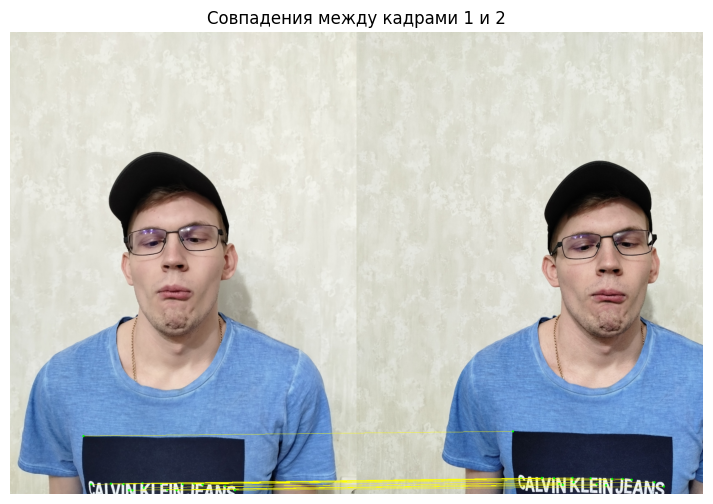


  Сопоставление 2 → 3:
    Найдено 6 предварительных совпадений
    После фильтрации: 3 совпадений
    Преобразование: угол=0.00°, сдвиг=(-87.67, 305.33)
    Ошибка: 0.6540


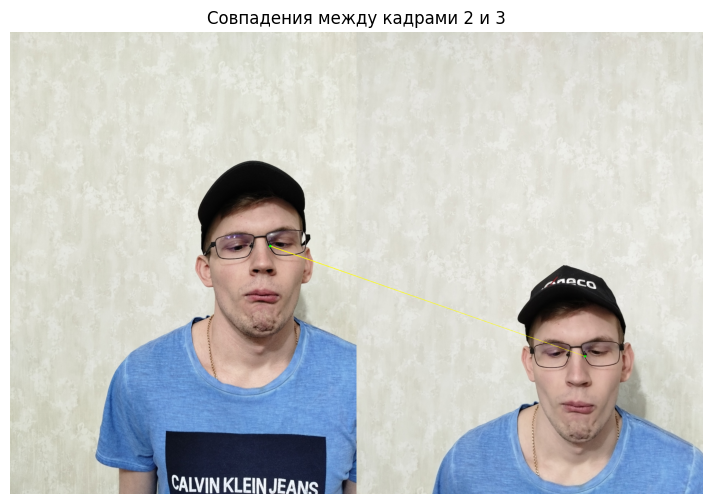


  Сопоставление 3 → 4:
    Найдено 5 предварительных совпадений
    После фильтрации: 3 совпадений
    Преобразование: угол=0.00°, сдвиг=(-400.00, -27.00)
    Ошибка: 0.6667


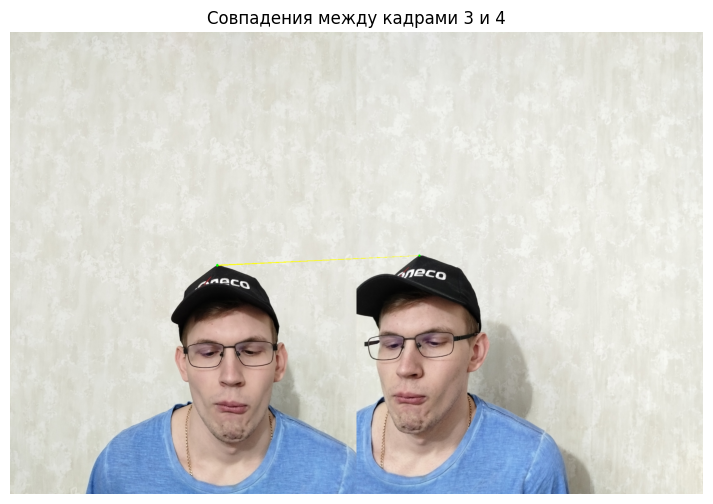


  Сопоставление 4 → 5:
    Найдено 13 предварительных совпадений
    После фильтрации: 7 совпадений
    Преобразование: угол=16.16°, сдвиг=(299.02, -412.78)
    Ошибка: 1.1356


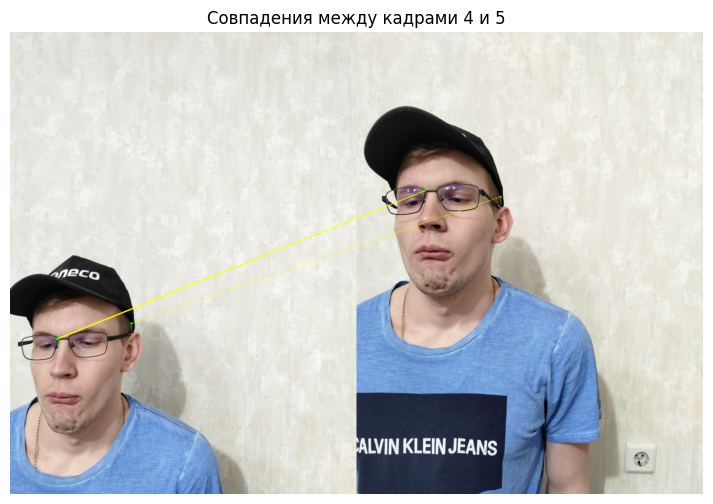


  Сопоставление 5 → 6:
    Найдено 26 предварительных совпадений
    После фильтрации: 4 совпадений
    Преобразование: угол=-10.27°, сдвиг=(140.50, 118.33)
    Ошибка: 1.0700


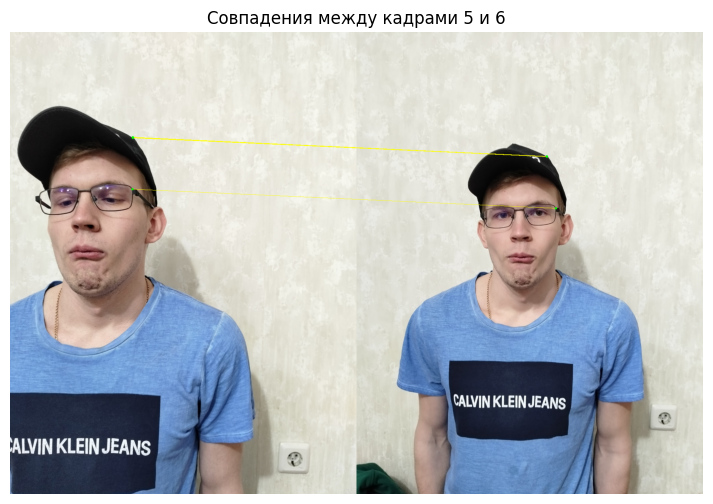


  Сопоставление 6 → 7:
    Найдено 7 предварительных совпадений
    После фильтрации: 0 совпадений
 Недостаточно совпадений

  Сопоставление 7 → 8:
    Найдено 8 предварительных совпадений
    После фильтрации: 4 совпадений
    Преобразование: угол=0.00°, сдвиг=(35.50, -434.50)
    Ошибка: 0.7071


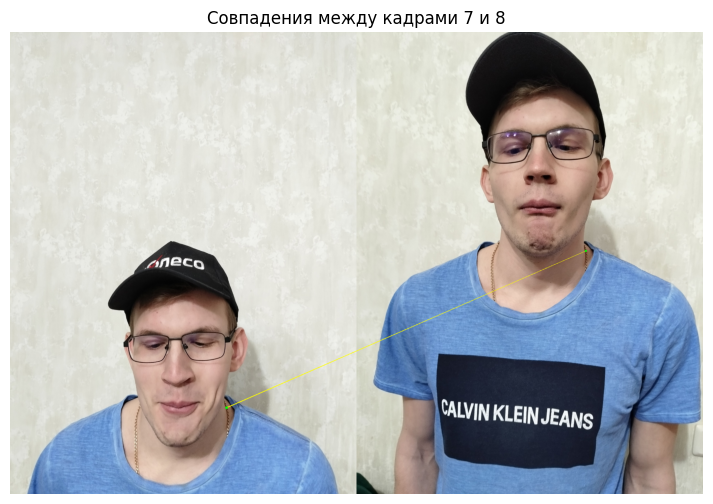


Построение траектории...


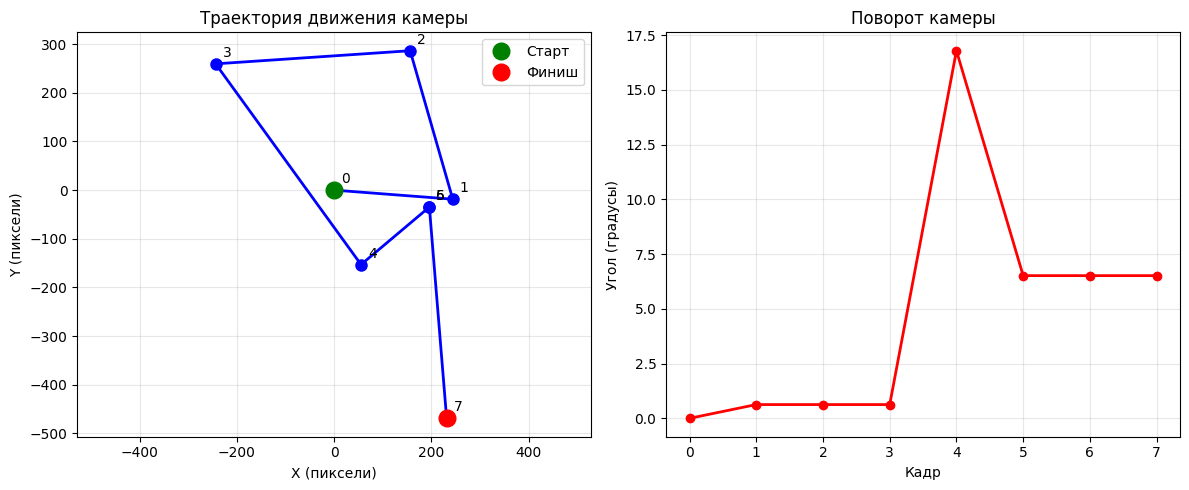


РЕЗУЛЬТАТЫ

Итоговая траектория:
  Кадр 0: позиция (0.00, 0.00), угол 0.00°
  Кадр 1: позиция (244.09, -18.69), угол 0.63°
  Кадр 2: позиция (156.43, 286.65), угол 0.63°
  Кадр 3: позиция (-243.57, 259.65), угол 0.63°
  Кадр 4: позиция (55.45, -153.13), угол 16.79°
  Кадр 5: позиция (195.95, -34.80), угол 6.52°
  Кадр 6: позиция (195.95, -34.80), угол 6.52°
  Кадр 7: позиция (231.45, -469.30), угол 6.52°
 Результаты сохранены в /content/visual_odometry_results


In [16]:
image_folder = 'D:/CV/Lab_2'
positions, angles, matches = process_visual_odometry(image_folder, num_images=8)